# Global Albedo Finder
## Give every lat and lon an albedo
### Been thinking about this for weeks... 

Okay so, using our simulation data, we can run essentially every single pixel through albedo interpolation to get an idea of surface albedo from every location on Titan. I want to see exactly HOW robust this is. Can we see the shapes of the dunes? Can we identify global gradients? It's time to find out! 

Go over the entire Database. For EVERY pixel:

Grab lat, lon, I/F for the windows, and other relevant data. 

Determine where on Titan we consider the pixel to be.

Retrieve the albedo for each of the eight windows using the simulation data we already have. 

Add that albedo to a global map, which essentially has one plane per window (so 8 windows). 

We also want some idea of which cubes are in each location, so we can remove them if they're causing problems.

We also want to add together the poles, but that can be done afterward.




In [1]:
### PARAMETER SETTING
#This is where you tell the program what restrictions it should have on its observations.

inputFile = "AcceptableCubes.csv" #Shoudl be a "...CubeList" file made by DatabaseSearcher. Includes flyby and cube number, nothing else. 
inputFile = "..\\DatabaseSearcher\\" + inputFile

#Set values you want to check to True.
resolutionCheck = True #Restrict to a certain resolution classificaiton.

#resolutionCheck
#Note: resolution 0 pixels are considered errors. 
resUpperBound = 25.0 #25.0 is considered standard. 
resLowerBound = 0.0

#We only care about resolution here, unlike what happens when we usually run through the database.

modelNames = [

    #LAMBERTIAN MODEL DOOSE (NEW)
    ["newDooseA0.0LambSim0.93um.npy","New Doose Lambertian Model 0.9um A0.0"],
    ["newDooseA0.0LambSim1.08um.npy","New Doose Lambertian Model 1um A0.0"],
    ["newDooseA0.0LambSim1.27um.npy","New Doose Lambertian Model 1.3um A0.0"],
    ["newDooseA0.0LambSim1.59um.npy","New Doose Lambertian Model 1.6um A0.0"],
    ["newDooseA0.0LambSim2.01um.npy","Lambertian Model 2 microns 0.0 albedo"],
    ["newDooseA0.0LambSim2.69um.npy","New Doose Lambertian Model 2.7um A0.0"],
    ["newDooseA0.0LambSim2.79um.npy","New Doose Lambertian Model 2.8um A0.0"],
    ["newDooseA0.0LambSim5.00um.npy","New Doose Lambertian Model 5um A0.0"],

    ["newDooseA0.1LambSim0.93um.npy","New Doose Lambertian Model 0.9um A0.1"],
    ["newDooseA0.1LambSim1.08um.npy","New Doose Lambertian Model 1um A0.1"],
    ["newDooseA0.1LambSim1.27um.npy","New Doose Lambertian Model 1.3um A0.1"],
    ["newDooseA0.1LambSim1.59um.npy","New Doose Lambertian Model 1.6um A0.1"],
    ["newDooseA0.1LambSim2.01um.npy","Lambertian Model 2 micorns 0.1 albedo"],
    ["newDooseA0.1LambSim2.69um.npy","New Doose Lambertian Model 2.7um A0.1"],
    ["newDooseA0.1LambSim2.79um.npy","New Doose Lambertian Model 2.8um A0.1"],
    ["newDooseA0.1LambSim5.00um.npy","New Doose Lambertian Model 5um A0.1"],

    ["newDooseA0.2LambSim0.93um.npy","New Doose Lambertian Model 0.9um A0.2"],
    ["newDooseA0.2LambSim1.08um.npy","New Doose Lambertian Model 1um A0.2"],
    ["newDooseA0.2LambSim1.27um.npy","New Doose Lambertian Model 1.3um A0.2"],
    ["newDooseA0.2LambSim1.59um.npy","New Doose Lambertian Model 1.6um A0.2"],
    ["newDooseA0.2LambSim2.01um.npy","Lambertian Model 2 microns 0.2 albedo"],
    ["newDooseA0.2LambSim2.69um.npy","New Doose Lambertian Model 2.7um A0.2"],
    ["newDooseA0.2LambSim2.79um.npy","New Doose Lambertian Model 2.8um A0.2"],
    ["newDooseA0.2LambSim5.00um.npy","New Doose Lambertian Model 5um A0.2"],

  
]

import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import math
import os

#Add more files to load in as you desire. The format for doing so should be self-evident.

loadedModels = []
for filename in modelNames:
    truename = "..\\ModelCreator\\" + filename[0]
    loadedModels.append(np.load(truename)) #The first name is the one we want, the second is just a label.

#Clean the models, some may retain nans or -1 values. Set these to 0. 
#originally the code was able to handle these but I have no idea what I changed to break it. So we clean them here.
i,j,k,m = 0,0,0,0
while (m < len(loadedModels)):
    i = 0
    while (i < len(loadedModels[0])):
        j = 0
        while (j < len(loadedModels[0][0])):
            k = 0
            while (k < len(loadedModels[0][0][0])):
                if (math.isnan(loadedModels[m][i][j][k] )):
                    loadedModels[m][i][j][k]  = 0
                elif (loadedModels[m][i][j][k] < 0):
                    loadedModels[m][i][j][k] = 0
                if (modelNames[m][0] == "SpecularModel2.00um.npy" or modelNames[m][0] == "LambertianModel2.00um.npy"):
                    loadedModels[m][i][j][k] = loadedModels[m][i][j][k]*8. #The older models need this correcting factor.
                k = k+1
            j = j+1
        i = i+1
    m = m+1

#we have supplemental information files we may wish to access and compare to the loadedModels. 

loadedModelCounts = [] #How many times did we hit each point in reality? Used to identify which points are real data and not interpolated.
loadedModelCubs = [] #In case you wanted to know which cubes were used. Note that some cubes are repated, due to being used a ton of times. This
# was not originally intentional but we have decided to keep it as it allows us to "weight" cubes involved in certain situations.
loadedModelStdevs = []


for filename in modelNames:
    truename = "..\\ModelCreator\\" + filename[0].removesuffix(".npy") + "Counts.npy"
    if os.path.isfile(truename): loadedModelCounts.append(np.load(truename)) 
    else: loadedModelCounts.append("N") #Single character because strings are read as arrays, fun. N for NO. 

for filename in modelNames:
    truename = "..\\ModelCreator\\" + filename[0].removesuffix(".npy") + "Cubs.npy"
    if os.path.isfile(truename): loadedModelCubs.append(np.load(truename, allow_pickle = True)) #REMEMBER THE PICKLE
    else: loadedModelCubs.append("N") 

for filename in modelNames:
    truename = "..\\ModelCreator\\" + filename[0].removesuffix(".npy") + "Stdev.npy"
    if os.path.isfile(truename): loadedModelStdevs.append(np.load(truename))
    else: loadedModelStdevs.append("N") 

#No need to clean these as they will be supplementary to the loadedModels, you won't read them without the models.

def tripleAlbedoRetrieve(measurement,albedo0,albedo1,albedo2):
    #When calling this function, we assume...
    #First, the simple ones are just linear interpolaton. 
    foundAlbedo = 1
    if ((measurement > albedo0) and (measurement < albedo1)):
        foundAlbedo = 0.0 + 0.1*((measurement-albedo0)/(albedo1-albedo0)) #0.0 to 0.1
    elif ((measurement > albedo1) and (measurement < albedo2)):
        foundAlbedo = 0.1 + 0.1*((measurement-albedo1)/(albedo2-albedo1)) #0.1 to 02
    elif (measurement == albedo0):
        foundAlbedo = 0.0
    elif (measurement == albedo1):
        foundAlbedo = 0.1
    elif (measurement == albedo2):
        foundAlbedo = 0.2 #I highly doubt data will ever be EXACT like this, but we need to catch the possibility. 
    else: #Now we have to EXTRAPOLATE. Use all three points to get the most data. 
        coefficients = np.polyfit([albedo0, albedo1, albedo2], [0.0,0.1,0.2], 1) #last number is the Order here. 1 is linear.
        equation = np.poly1d(coefficients)
        foundAlbedo = equation(measurement)
    return foundAlbedo

In [ ]:
flyby = "TA"

#Imports
import csv
import math
import numpy as np
import scipy.misc

# The big data structure! Or structures. We need to feed it lat, lon, and wavelength to arrive at a list of retrieved albedos.
# We also want to retain a related cubelist so we can track where the data in each location came from. 

globalRetrievedIF = [[[[] for x in range(8)] for x in range(360)] for x in range(181)] #lat, lon, wavelength window
globalRetrievedAlbedos = [[[[] for x in range(8)] for x in range(360)] for x in range(181)] #lat, lon, wavelength window
globalRetrievedObsAngles = [[[[] for x in range(3)] for x in range(360)] for x in range(181)] #lat, lon, observation angle
globalRetrievedCubeList = [[[] for x in range(360)] for x in range(181)] #No wavelength dependence.

#First, read in the data into a matrix. 
cubeList = []
with open(inputFile) as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        triplet = ["A","A"]
        triplet[0] = row[0]
        triplet[1] = row[1]
        cubeList.append(triplet)
        line_count += 1

for item in cubeList:
    err = 0 #No error by default.
    
    #This code is copy adapted from the VIMS Cube Visualisation Interface Notebook. 
    #It is complicated.
    filepath = "C:\\Users\\deran\\Desktop\\CubeCSVDatabase\\" + item[0] + "\\CM_" + item[1] + ".cub.csv"
    
    #Now we extract the axes file as well...
    cubeAxesfp = filepath.removesuffix(".csv") + ".axes.csv"
    #and the geo files. 
    cubeGeofpIR = filepath.removesuffix(".cub.csv") + "_ir_geo.cub.csv"
    cubeGeofpIRaxes = filepath.removesuffix(".cub.csv") + "_ir_geo.cub.axes.csv"

    #Skeleton code nabbed from https://realpython.com/python-csv/
    
    #Step 1: use the axes to determine the size of what we're dealing with.
    xAxisCube = []
    yAxisCube = []
    zAxisCube = []
    
    xAxisGeoIR = []
    yAxisGeoIR = []
    zAxisGeoIR = []

    if (item[0] == flyby):

        try:
            with open(cubeAxesfp) as csv_file: #remember to tab.
                    csv_reader = csv.reader(csv_file, delimiter=',')
                    line_count = 0
                    for row in csv_reader:
                        i = 0
                        L = len(row)
                        while (i < L-1):
                            if (line_count == 0):
                                xAxisCube.append(row[i])
                            elif (line_count == 1):
                                yAxisCube.append(row[i])
                            elif (line_count == 2):
                                zAxisCube.append(row[i])
                            i = i+1
                        line_count += 1
        except:
            print("No Cube Axes", item[0], item[1])
            err = 1 #whoops.        
        try:
            with open(cubeGeofpIRaxes) as csv_file: #remember to tab.
                    csv_reader = csv.reader(csv_file, delimiter=',')
                    line_count = 0
                    for row in csv_reader:
                        i = 0
                        L = len(row)
                        while (i < L-1):
                            if (line_count == 0):
                                xAxisGeoIR.append(row[i])
                            elif (line_count == 1):
                                yAxisGeoIR.append(row[i])
                            elif (line_count == 2):
                                zAxisGeoIR.append(row[i])
                            i = i+1
                        line_count += 1
        except:
            print("No Geo Axes", item[0], item[1])
            err = 1 #whoops.
            
        #We now have an x, y, and z axis. x and y axes are just ordinal, but the z axis contains wavelength in microns.
        #The lengths of these arrays tell us how to extract the data.
        
        cubeData = [[[0 for x in range(len(zAxisCube))] for x in range(len(yAxisCube))] for x in range(len(xAxisCube))]
        geoIRData = [[[0 for x in range(len(zAxisGeoIR))] for x in range(len(yAxisGeoIR))] for x in range(len(xAxisGeoIR))]
        
        #The above holds the data of the cube itself. 
        try:
            with open(filepath) as csv_file:
                csv_reader = csv.reader(csv_file, delimiter=',')
                line_count = 0
                i, j, k = 0, 0, 0
                for row in csv_reader:
                    while (i < len(xAxisCube)):
                        cubeData[i][j][k] = float(row[i])
                        if (math.isnan(cubeData[i][j][k])):
                            cubeData[i][j][k] = 0 #We set nans to zero to allow plotting to take place, careful!
                        elif (cubeData[i][j][k] < 0):
                            cubeData[i][j][k] = 0 #Negative values are nonsense.
                        elif (cubeData[i][j][k] > 1):
                            cubeData[i][j][k] = 1 #Make saturation obvious? Keep it from overloading. 
                        i = i + 1
                    i = 0
                    j = j + 1
                    if (j >= len(yAxisCube)):
                        j = 0
                        k = k + 1
                    line_count += 1
        except:
            print("No Cube File (how?)", item[0], item[1])
            err = 1 #whoops.
        try:
            with open(cubeGeofpIR) as csv_file:
                csv_reader = csv.reader(csv_file, delimiter=',')
                line_count = 0
                i, j, k = 0, 0, 0
                for row in csv_reader:
                    while (i < len(xAxisGeoIR)):
                        geoIRData[i][j][k] = float(row[i])
                        if (math.isnan(geoIRData[i][j][k])):
                            geoIRData[i][j][k] = 0 #We set nans to zero to allow plotting to take place, careful!
                        elif (geoIRData[i][j][k] < -1000):
                            geoIRData[i][j][k] = 0 #The default value is an extremely negative number. Scrub it.
                        i = i + 1
                    i = 0
                    j = j + 1
                    if (j >= len(yAxisGeoIR)):
                        j = 0
                        k = k + 1
                    line_count += 1
        except:
            print("No Geo File", item[0], item[1])
            err = 1 #Whoops.
        #The data is now read in.
    else:
        err = 1
    #BOOKKEEPING: declare where the windows are. 
    windowum = [0.933078, 1.08183, 1.27813, 1.59018, 2.01781, 2.69620, 2.79889, 5.00576]
    windowInd = [99, 108, 120, 139, 165, 206, 212, 344]
    windowIndAlt = [3,12,24,43,69,110,116,248]
    if (len(zAxisCube) <= 256):
        windowInd = windowIndAlt #Sometimes the cubes have different indeces. It's weird,  yeah, but this is how we check for that. 

    print("Working", item[0], item[1])
        
    #Now we can do stuff with the data. In this case, we need to examine every pixel and print out the "viable" ones to a file.
    if (err == 0):
        x,y = 0,0 
        while (x < len(xAxisCube)):
            y = 0
            while (y < len(yAxisCube)):
                #Inintial checks of pixel locaiton and resolution. Only continue if tests passed. 
                if((resolutionCheck == False) or 
                   (resUpperBound > geoIRData[x][y][2] and 
                    resLowerBound < geoIRData[x][y][2] and geoIRData[x][y][2] != 0.0)):

                    #Now at this point we perform the mask test, but we have to start gatehring some values before we can do that. 

                    lat = geoIRData[x][y][0]
                    lon = geoIRData[x][y][1]
                    #Round to the nearest whole number.
                    lat = int(np.rint(lat))
                    lon = 360 - int(np.rint(lon)) #Have to flip our longitude. 
                    #not because it's wrong, but because the INDEX of the MASK is FLIPPED.
                    if (lon >= 360): lon = 0
                    if (lat <= -90): lat = -90
                    #Now these are our latlon coordinates. We can use them to find the mask we need.

                    temp = np.transpose(cubeData)
  
                    inci = geoIRData[x][y][5]
                    #So uh if incidence is MUCh higher than 100 we need to not use it.
                    badPoint = False
                    if (inci > 102.5): badPoint = True
                    emis = geoIRData[x][y][6]
                    azim = 0.
                    #Azimuth formula from Jason Barnes' phasecurve.c++
                    p = geoIRData[x][y][4] #used to calculate azimuth.
                    ratio = -(np.cos(np.radians(p)) - np.cos(np.radians(inci))* np.cos(np.radians(emis)))/(np.sin(np.radians(inci))*np.sin(np.radians(emis)))
                    azim = np.arccos(ratio)
                    #Of course, this might be nan-ing. All the nans need their own values.
                    if((math.isnan(azim) == True) and (ratio>0.)):
                        azim = 0.
                    elif((math.isnan(azim) == True) and (ratio<0.)):
                        azim = 0.
                    elif((inci==0) and (emis==0)):
                        azim = 0.
                    elif(math.isnan(azim) == True):
                        print("Well you broke it, great. (Azimuth is nan, but could not be set to anything else.)")
                    if (inci < 0):
                        inci = 0
                    elif (inci > 100):
                        inci = 100
                    if (emis < 0):
                        emis = 0
                    elif (emis > 90):
                        emis = 90
                    if (azim < 0):
                        azim = 0
                    if (azim > 180):
                        azim = 180

                    inciCoor = int(np.round(inci/5.))
                    emisCoor = int(np.round(emis/5.))
                    azimCoor = int(np.round(azim/5.))

                    windowVals = [np.transpose(temp[windowInd[0]])[x][y],
                                 np.transpose(temp[windowInd[1]])[x][y],
                                 np.transpose(temp[windowInd[2]])[x][y],
                                 np.transpose(temp[windowInd[3]])[x][y],
                                 np.transpose(temp[windowInd[4]])[x][y],
                                 np.transpose(temp[windowInd[5]])[x][y],
                                 np.transpose(temp[windowInd[6]])[x][y],
                                 np.transpose(temp[windowInd[7]])[x][y]]

                    ofs = 96

                    if (windowInd[7] == 344):
                        ofs = 0 

                    windowVals[7] = (np.transpose(temp[336-ofs])[x][y]+np.transpose(temp[337-ofs])[x][y]+np.transpose(temp[338-ofs])[x][y]
                                          +np.transpose(temp[339-ofs])[x][y]+np.transpose(temp[340-ofs])[x][y]+np.transpose(temp[341-ofs])[x][y]
                                          +np.transpose(temp[342-ofs])[x][y]+np.transpose(temp[343-ofs])[x][y]+np.transpose(temp[344-ofs])[x][y]
                                          +np.transpose(temp[345-ofs])[x][y]+np.transpose(temp[346-ofs])[x][y]+np.transpose(temp[347-ofs])[x][y]
                                          +np.transpose(temp[348-ofs])[x][y]+np.transpose(temp[349-ofs])[x][y]+np.transpose(temp[350-ofs])[x][y]+np.transpose(temp[351-ofs])[x][y])/16.
                    #print(outfile)
                    if (badPoint == False): #Only continue if we're good man. 
                        #print(windowVals)
                        globalRetrievedObsAngles[lat+90][lon][0].append(inci) #We MUST ensure that each of these is written every time.
                        globalRetrievedObsAngles[lat+90][lon][1].append(emis) #Otherwise later comparisons will be absolutely pointless.
                        globalRetrievedObsAngles[lat+90][lon][2].append(azim) 
                        globalRetrievedCubeList[lat+90][lon].append(item[1])
                        
                        w = 0
                        while (w < 8):
                            aa0 = loadedModels[w][inciCoor][emisCoor][azimCoor]
                            aa1 = loadedModels[w+8][inciCoor][emisCoor][azimCoor]
                            aa2 = loadedModels[w+16][inciCoor][emisCoor][azimCoor]
                            globalRetrievedIF[lat+90][lon][w].append(windowVals[w])
                            if (aa0 < aa1 and aa1 < aa2): #Points are physical, be normal!
                                globalRetrievedAlbedos[lat+90][lon][w].append(tripleAlbedoRetrieve(windowVals[w],aa0,aa1,aa2))
                            else: #Something freaky has happened.
                                if (aa1 == 0 and aa0 < aa2): #missing data point is fine, go ahead and interpolate with just the two. This also works as extrapolation if necessary!
                                    globalRetrievedAlbedos[lat+90][lon][w].append(0.0 + 0.2*((windowVals[w]-aa0) / (aa2-aa0)))
                                elif (aa2 == 0 and aa0 < aa1): #missing data point is fine, go ahead and interpolate with just the two.
                                    globalRetrievedAlbedos[lat+90][lon][w].append(0.0 + 0.1*((windowVals[w]-aa0) / (aa1-aa0)))
                                else:
                                    globalRetrievedAlbedos[lat+90][lon][w].append(np.nan)
                                    #Notably, if aa0==0, then the normal albedo retrieve function will work just fine and we won't even be here.
                            #print(aa0,aa1,aa2,windowVals[w],tripleAlbedoRetrieve(windowVals[w],aa0,aa1,aa2), inci, emis, azim, item[1])
                            #There were various nan adding checks here, but as we're simply appending the results, they were deemed not necessary.
                            w=w+1                       
                y=y+1
            x=x+1 

import awkward as ak #For inhomogenous arrays, which the below are.
import pyarrow

save = ak.Array(globalRetrievedIF)
ak.to_parquet(save,"globalRetrievedIF" + flyby + ".parquet")

save = ak.Array(globalRetrievedAlbedos)
ak.to_parquet(save,"globalRetrievedAlbedos" + flyby + ".parquet")

save = ak.Array(globalRetrievedObsAngles)
ak.to_parquet(save,"globalRetrievedObsAngles" + flyby + ".parquet")

save = ak.Array(globalRetrievedCubeList)
ak.to_parquet(save,"globalRetrievedCubeList" + flyby + ".parquet")
    
#ADD SANITY CHECKER HERE IF NEEDED

C:\Users\deran\AppData\Local\Temp\ipykernel_30324\298014449.py:7: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  import scipy.misc


Working TA 1477229290_1
Working TA 1477235195_1
Working TA 1477241480_1
Working TA 1477248375_1
Working TA 1477254708_1
Working TA 1477259641_1
Working TA 1477264974_1
Working TA 1477342011_1
Working TA 1477350966_1
Working TA 1477359966_1
Working TA 1477370646_1
Working TA 1477377936_1
No Cube File (how?) TA 1477417363_1
Working TA 1477417363_1
Working TA 1477417742_1
Working TA 1477434729_1
Working TA 1477435094_1
Working TA 1477435193_1
Working TA 1477435558_1


In [ ]:
import awkward as ak #For inhomogenous arrays, which the below are.
import pyarrow

save = ak.Array(globalRetrievedAlbedos)
ak.to_parquet(save,"glogalRetrievedAlbedos.parquet")

save = ak.Array(globalRetrievedObsAngles)
ak.to_parquet(save,"glogalRetrievedObsAngles.parquet")

save = ak.Array(globalRetrievedCubeList)
ak.to_parquet(save,"glogalRetrievedCubeList.parquet")

In [ ]:
import awkward as ak #For inhomogenous arrays, which the below are.
flyby = "TA"
globalRetrievedIFNew = ak.from_parquet("globalRetrievedIFALL.parquet")
globalRetrievedAlbedosNew = ak.from_parquet("globalRetrievedAlbedosALL.parquet")
globalRetrievedObsAnglesNew = ak.from_parquet("globalRetrievedObsAnglesALL.parquet")
globalRetrievedCubeListNew = ak.from_parquet("globalRetrievedCubeListALL.parquet")

In [4]:

import numpy as np
wavs = ["0.93um","1.08um","1.27um","1.59um","2.01um","2.69um","2.79um","5.00um"]

#For dealing with the fat pixels.
binSize = [360, 30, 20, 15, 12, 10, 8, 6, 6, 5,
           5, 4, 4, 4, 3, 3, 3, 3, 3, 2, 
           2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
           1, # at 0 here 
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
           2, 3, 3, 3, 3, 3, 4, 4, 4, 5, 
           5, 6, 6, 8, 10, 12, 15, 20, 30, 360]

def mapGen(wav, useCombinedPixels): #add another flag later to allow for MAD retrieval and other such things, like examining multiple windows and the like.
    titanMap = [[0 for x in range(360)] for x in range(181)]

    lat = -90
    while (lat < 91):
        lon = 360
        while (lon > 0):
            if(useCombinedPixels==False):
                #median magic here
                thisMedian = np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][wav]) #does this break if there are no values...?
                #absDeviation = np.abs(globalRetrievedAlbedosNew[90-lat][360-lon][wav] - thisMedian)
                #theMAD = np.median(absDeviation)*1.4826
                titanMap[90-lat][360-lon] = thisMedian
                lon = lon-1
            else: #Miiiight be working...? This is for "fat pixels," as 1x1 latlon at the poles is not the same as at the equator, so this is an attempt to minimize that.
                albedoBuffer = []
                for item in globalRetrievedAlbedosNew[lat+90][360-lon][wav]:
                    albedoBuffer.append(item)
                i = 1
                while (i < binSize[90-lat]):
                    for item in globalRetrievedAlbedosNew[lat+90][360-lon+i][wav]:
                        albedoBuffer.append(item)
                    i=i+1

                titanMap[90-lat][360-lon] = np.nanmedian(albedoBuffer)
                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
                    i=i+1
                lon = lon - binSize[lat+90]

            
        lat = lat+1
              
    return titanMap

def mapGenIF(wav, useCombinedPixels): #add another flag later to allow for MAD retrieval and other such things, like examining multiple windows and the like.
    titanMap = [[0 for x in range(360)] for x in range(181)]

    lat = -90
    while (lat < 91):
        lon = 360
        while (lon > 0):
            if(useCombinedPixels==False):
                #median magic here
                thisMedian = np.median(globalRetrievedIFNew[lat+90][360-lon][wav]) #does this break if there are no values...?
                #absDeviation = np.abs(globalRetrievedAlbedosNew[90-lat][360-lon][wav] - thisMedian)
                #theMAD = np.median(absDeviation)*1.4826
                titanMap[90-lat][360-lon] = thisMedian
                lon = lon-1
            else: #Miiiight be working...? This is for "fat pixels," as 1x1 latlon at the poles is not the same as at the equator, so this is an attempt to minimize that.
                albedoBuffer = []
                for item in globalRetrievedIFNew[lat+90][360-lon][wav]:
                    albedoBuffer.append(item)
                i = 1
                while (i < binSize[90-lat]):
                    for item in globalRetrievedIFNew[lat+90][360-lon+i][wav]:
                        albedoBuffer.append(item)
                    i=i+1

                titanMap[90-lat][360-lon] = np.median(albedoBuffer)
                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
                    i=i+1
                lon = lon - binSize[lat+90]

            
        lat = lat+1
              
    return titanMap

def mapGenShallowBORQ(wav, useCombinedPixels): #add another flag later to allow for MAD retrieval and other such things, like examining multiple windows and the like.
    titanMap = [[0 for x in range(360)] for x in range(181)]

    globalRetrievedObsAnglesNewBORQ = globalRetrievedObsAnglesNew[:,:,:,::8] #Every eigth one, since some moron (me) 
    #Did this every wavelength. When the data is officially fixed, remove this line.
    
    specificWindowAlbedos = globalRetrievedAlbedosNew[:,:,wav]
    obsAngles = globalRetrievedObsAnglesNewBORQ[:,:,1]  
    mask = (obsAngles<= 40)
    lenAlbedo = ak.num(specificWindowAlbedos, axis=-1)
    lenAngles = ak.num(obsAngles, axis=-1)
    differenceLen = lenAlbedo - lenAngles
    filteredData = specificWindowAlbedos[mask]

    titanMap = [[0 for x in range(360)] for x in range(181)]

    lat = -90
    while (lat < 91):
        lon = 360
        while (lon > 0):
            if(useCombinedPixels==False):
                #median magic here
                thisMedian = np.nanmedian(filteredData[lat+90][360-lon]) #does this break if there are no values...?
                #absDeviation = np.abs(globalRetrievedAlbedosNew[90-lat][360-lon][wav] - thisMedian)
                #theMAD = np.median(absDeviation)*1.4826
                titanMap[90-lat][360-lon] = thisMedian
                lon = lon-1
            else: #Miiiight be working...? This is for "fat pixels," as 1x1 latlon at the poles is not the same as at the equator, so this is an attempt to minimize that.
                albedoBuffer = []
                for item in filteredData[lat+90][360-lon]:
                    albedoBuffer.append(item)
                i = 1
                while (i < binSize[90-lat]):
                    for item in filteredData[lat+90][360-lon]:
                        albedoBuffer.append(item)
                    i=i+1

                titanMap[90-lat][360-lon] = np.nanmedian(albedoBuffer)
                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
                    i=i+1
                lon = lon - binSize[lat+90]

            
        lat = lat+1
              
    return titanMap

def mapGenMAD(wav, useCombinedPixels): #add another flag later to allow for MAD retrieval and other such things, like examining multiple windows and the like.
    titanMap = [[0 for x in range(360)] for x in range(181)]

    lat = -90
    while (lat < 91):
        lon = 360
        while (lon > 0):
            if(useCombinedPixels==False):
                #median magic here
                thisMedian = np.nanmedian(globalRetrievedIFNew[lat+90][360-lon][wav]) #does this break if there are no values...?
                absDeviation = np.abs(globalRetrievedAlbedosNew[90-lat][360-lon][wav] - thisMedian)
                theMAD  = np.nanmedian(absDeviation)*1.4826
                titanMap[90-lat][360-lon] = theMAD
                lon = lon-1
            else: #Miiiight be working...? This is for "fat pixels," as 1x1 latlon at the poles is not the same as at the equator, so this is an attempt to minimize that.
                albedoBuffer = []
                for item in globalRetrievedIFNew[lat+90][360-lon][wav]:
                    albedoBuffer.append(item)
                i = 1
                while (i < binSize[90-lat]):
                    for item in globalRetrievedIFNew[lat+90][360-lon+i][wav]:
                        albedoBuffer.append(item)
                    i=i+1

                thisMedian = np.nanmedian(albedoBuffer) #does this break if there are no values...?
                absDeviation = np.abs(albedoBuffer - thisMedian)
                theMAD  = np.nanmedian(absDeviation)*1.4826
                titanMap[90-lat][360-lon] = theMAD
                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
                    i=i+1
                lon = lon - binSize[lat+90]

            
        lat = lat+1
              
    return titanMap

def mapGenPixelCounts(wav, useCombinedPixels): #add another flag later to allow for MAD retrieval and other such things, like examining multiple windows and the like.
    titanMap = [[0 for x in range(360)] for x in range(181)]

    lat = -90
    while (lat < 91):
        lon = 360
        while (lon > 0):
            if(useCombinedPixels==False):
                titanMap[90-lat][360-lon] = len(globalRetrievedAlbedosNew[lat+90][360-lon][wav])
                lon = lon-1
            else: #Miiiight be working...? This is for "fat pixels," as 1x1 latlon at the poles is not the same as at the equator, so this is an attempt to minimize that.

                titanMap[90-lat][360-lon] = len(globalRetrievedAlbedosNew[lat+90][360-lon][wav])
                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon] = titanMap[90-lat][360-lon] + len(globalRetrievedAlbedosNew[lat+90][360-lon+i][wav])
                    i=i+1
                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
                    i=i+1
                lon = lon - binSize[lat+90]

            
        lat = lat+1
              
    return titanMap

def mapGenCubeCounts(wav, useCombinedPixels): #add another flag later to allow for MAD retrieval and other such things, like examining multiple windows and the like.
    titanMap = [[0 for x in range(360)] for x in range(181)]

    lat = -90
    while (lat < 91):
        lon = 360
        while (lon > 0):
            if(useCombinedPixels==False):
                titanMap[90-lat][360-lon] = len(set(globalRetrievedCubeListNew[lat+90][360-lon]))
                lon = lon-1
            else: #Miiiight be working...? This is for "fat pixels," as 1x1 latlon at the poles is not the same as at the equator, so this is an attempt to minimize that.
                allCubes = globalRetrievedCubeListNew[lat+90][360-lon]
                i = 1
                while (i < binSize[90-lat]):
                    allCubes = ak.flatten([allCubes, globalRetrievedCubeListNew[lat+90][360-lon+i]])
                    i=i+1
                    
                titanMap[90-lat][360-lon] = len(set(allCubes))

                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
                    i=i+1
                lon = lon - binSize[lat+90]

            
        lat = lat+1
              
    return titanMap

def mapSimilarityGradient(): #look I have no reason to want to do this without combined pixels so who cares, you get no options.
    #As it turns out, this was a terrible idea. No need to finish it.
    titanMap = [[0 for x in range(360)] for x in range(181)]
    lat = -90
    while (lat < 91):
        lon = 360
        while (lon > 0):
            #our goal here is to get a measure of how quickly the retrieved albedos change by considering the pixels adjacent to each bin. 
            #Unfortunately some pixels are fat so this is somewhat complicated.
            #We have three cases: Poles, Fat Pixels, and Normal Pixels.
            if (lat == -90 or lat == 90): 
                titanMap[90-lat][360-lon] = 0
                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
                    i=i+1
            elif (binSize[90-lat] > 1):
                titanMap[90-lat][360-lon] = 0
                i = 1
                while (i < binSize[90-lat]):
                    titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
                    i=i+1
            else:
                #Hey look, we can be normal!

                #quick and dirty weird check:
                lon2 = lon
                if lon2 == 1: lon2 = 361
                #This doesn't need to be done the other way since negative indices loop automatically. Neat!
                
                retrievedAlbedoList = [#np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][0]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][1]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][2]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][3]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][4]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][5]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][6]),                                                 
                                    np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][4])]
                retrievedAlbedoListUp = [#np.nanmedian(globalRetrievedAlbedosNew[lat+91][360-lon][0]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+91][360-lon][1]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+91][360-lon][2]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+91][360-lon][3]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+91][360-lon][4]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+91][360-lon][5]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+91][360-lon][6]),                                                 
                                    np.nanmedian(globalRetrievedAlbedosNew[lat+91][360-lon][4])]
                retrievedAlbedoListDown = [#np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][0]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+89][360-lon][1]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+89][360-lon][2]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+89][360-lon][3]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+89][360-lon][4]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+89][360-lon][5]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+89][360-lon][6]),                                                 
                                    np.nanmedian(globalRetrievedAlbedosNew[lat+89][360-lon][4])]                                                
                retrievedAlbedoListLeft = [#np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][0]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][359-lon][1]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][359-lon][2]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][359-lon][3]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][359-lon][4]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][359-lon][5]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][359-lon][6]),                                                 
                                    np.nanmedian(globalRetrievedAlbedosNew[lat+90][359-lon][4])] 
                retrievedAlbedoListRight = [#np.nanmedian(globalRetrievedAlbedosNew[lat+90][360-lon][0]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][361-lon2][1]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][361-lon2][2]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][361-lon2][3]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][361-lon2][4]),                                                 
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][361-lon2][5]),
                                    #np.nanmedian(globalRetrievedAlbedosNew[lat+90][361-lon2][6]),                                                 
                                    np.nanmedian(globalRetrievedAlbedosNew[lat+90][361-lon2][4])]

                simiGrad = (np.sum(np.abs(np.array(retrievedAlbedoList) - np.array(retrievedAlbedoListUp)))
                        + np.sum(np.abs(np.array(retrievedAlbedoList) - np.array(retrievedAlbedoListDown)))
                        + np.sum(np.abs(np.array(retrievedAlbedoList) - np.array(retrievedAlbedoListLeft)))
                        + np.sum(np.abs(np.array(retrievedAlbedoList) - np.array(retrievedAlbedoListRight))))
    
                titanMap[90-lat][360-lon] = simiGrad
            lon = lon - binSize[lat+90]
        lat = lat+1
    return titanMap
    

In [60]:
mapSimiGrad = mapSimilarityGradient()
mask = np.load("TitanMask.titanMap.npy")
bool_mask = (mask == 0)
npMapSimiGrad = np.array(mapSimiGrad).astype(float)
npMapSimiGrad[bool_mask] = np.nan

\\?\C:\Users\deran\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
\\?\C:\Users\deran\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\awkward\_connect\numpy.py:112: RuntimeWarning: All-NaN slice encountered
  result = func(*rectilinear_args, **rectilinear_kwargs)


In [6]:
mapCubes = mapGenCubeCounts(4,True) #doesn't really matter what you put in here...
mapPixels = mapGenPixelCounts(4,True) #doesn't really matter what you put in here...

In [5]:
#Create (and save) a mask that will ignore all data from pixels deemed to have "not enough information"
titanMap = [[0 for x in range(360)] for x in range(181)]

lat = -90
while (lat < 91):
    lon = 360
    while (lon > 0):
        allCubes = globalRetrievedCubeListNew[lat+90][360-lon]
        i = 1
        while (i < binSize[90-lat]):
            allCubes = ak.flatten([allCubes, globalRetrievedCubeListNew[lat+90][360-lon+i]])
            i=i+1
        titanMap[90-lat][360-lon] = len(allCubes)
        if (titanMap[90-lat][360-lon] >= 4): titanMap[90-lat][360-lon] = 1
        else: titanMap[90-lat][360-lon] = 0
        i = 1
        while (i < binSize[90-lat]):
            titanMap[90-lat][360-lon+i] = titanMap[90-lat][360-lon]
            i=i+1
        lon = lon - binSize[lat+90]
    lat = lat+1

np.save("TitanMask.titanMap",titanMap)

In [7]:
#So we want to be able to look at all eight wavelengths at once. 
map0 = mapGen(0,True) #Make the map. Use the stretched pixels.
map1 = mapGen(1,True) #Make the map. Use the stretched pixels.
map2 = mapGen(2,True) #Make the map. Use the stretched pixels.
map3 = mapGen(3,True) #Make the map. Use the stretched pixels.
map4 = mapGen(4,True) #Make the map. Use the stretched pixels.
map5 = mapGen(5,True) #Make the map. Use the stretched pixels.
map6 = mapGen(6,True) #Make the map. Use the stretched pixels.
map7 = mapGen(7,True) #Make the map. Use the stretched pixels.
mapIF0 = mapGenIF(0,True) #Make the map. Use the stretched pixels.
mapIF1 = mapGenIF(1,True) #Make the map. Use the stretched pixels.
mapIF2 = mapGenIF(2,True) #Make the map. Use the stretched pixels.
mapIF3 = mapGenIF(3,True) #Make the map. Use the stretched pixels.
mapIF4 = mapGenIF(4,True) #Make the map. Use the stretched pixels.
mapIF5 = mapGenIF(5,True) #Make the map. Use the stretched pixels.
mapIF6 = mapGenIF(6,True) #Make the map. Use the stretched pixels.
mapIF7 = mapGenIF(7,True) #Make the map. Use the stretched pixels.


C:\Users\deran\AppData\Local\Temp\ipykernel_13284\692974631.py:49: RuntimeWarning: All-NaN slice encountered
  titanMap[90-lat][360-lon] = np.nanmedian(albedoBuffer)
\\?\C:\Users\deran\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
\\?\C:\Users\deran\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
\\?\C:\Users\deran\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [8]:
mask = np.load("TitanMask.titanMap.npy")
#FILTRATION TIME!!!
bool_mask = (mask == 0)
npMap0 = np.array(map0)
npMap0[bool_mask] = np.nan
npMap1 = np.array(map1)
npMap1[bool_mask] = np.nan
npMap2 = np.array(map2)
npMap2[bool_mask] = np.nan
npMap3 = np.array(map3)
npMap3[bool_mask] = np.nan
npMap4 = np.array(map4)
npMap4[bool_mask] = np.nan
npMap5 = np.array(map5)
npMap5[bool_mask] = np.nan
npMap6 = np.array(map6)
npMap6[bool_mask] = np.nan
npMap7 = np.array(map7)
npMap7[bool_mask] = np.nan
npMapIF0 = np.array(mapIF0)
npMapIF0[bool_mask] = np.nan
npMapIF1 = np.array(mapIF1)
npMapIF1[bool_mask] = np.nan
npMapIF2 = np.array(mapIF2)
npMapIF2[bool_mask] = np.nan
npMapIF3 = np.array(mapIF3)
npMapIF3[bool_mask] = np.nan
npMapIF4 = np.array(mapIF4)
npMapIF4[bool_mask] = np.nan
npMapIF5 = np.array(mapIF5)
npMapIF5[bool_mask] = np.nan
npMapIF6 = np.array(mapIF6)
npMapIF6[bool_mask] = np.nan
npMapIF7 = np.array(mapIF7)
npMapIF7[bool_mask] = np.nan
npMapCubes = np.array(mapCubes).astype(float)
npMapCubes[bool_mask] = np.nan

In [9]:
mask = np.load("TitanMask.titanMap.npy")
bool_mask = (mask == 0)
npMapCubes = np.array(mapCubes).astype(float)
npMapCubes[bool_mask] = np.nan
npMapPixels = np.array(mapPixels).astype(float)
npMapPixels[bool_mask] = np.nan

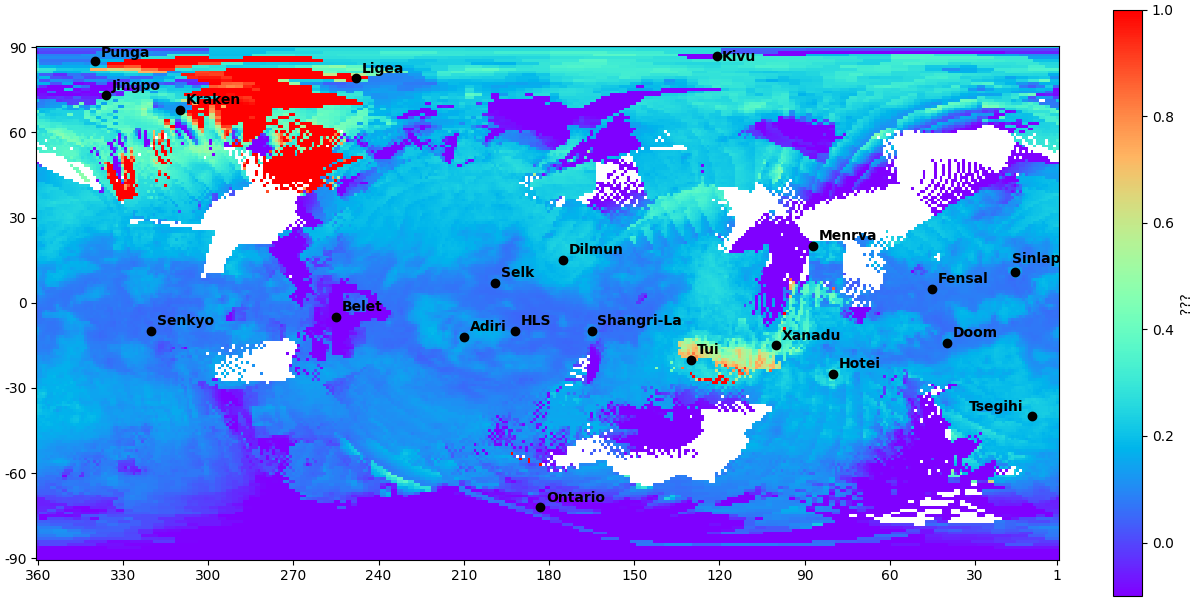

In [29]:
import matplotlib.pyplot as plt
%matplotlib ipympl 

#Filter the data through the mask for all eight wavelengths.
mask = np.load("TitanMask.titanMap.npy")
step=0.00001
#step 1: filtration
bool_mask = (mask == 0)
npMap0 = np.array(map0)
npMap0[bool_mask] = np.nan
npMap1 = np.array(map1)
npMap1[bool_mask] = np.nan
npMap2 = np.array(map2)
npMap2[bool_mask] = np.nan
npMap3 = np.array(map3)
npMap3[bool_mask] = np.nan
npMap4 = np.array(map4)
npMap4[bool_mask] = np.nan
npMap5 = np.array(map5)
npMap5[bool_mask] = np.nan
npMap6 = np.array(map6)
npMap6[bool_mask] = np.nan
npMap7 = np.array(map7)
npMap7[bool_mask] = np.nan
#Everything is now filtered out, with NaNs where we excised stuff. Now we need to make something with it. Original plan was a histogram, but that was useless.
fig, ax = plt.subplots(figsize = (12,6),layout="constrained")
image = ax.imshow(np.round(npMap4/step)*step, cmap = "rainbow",vmin = -0.1, vmax=1,interpolation="none")
cb = plt.colorbar(image, label = "???")

plt.scatter(360-192, 90+10,color="black")
plt.text(360-192+2, 90+10-2, "HLS", color="black", weight="bold")

plt.scatter(360-183, 90+72,color="black")
plt.text(360-183+2, 90+72-2, "Ontario", color="black", weight="bold")

plt.scatter(360-16, 90-11,color="black")
plt.text(360-16-1, 90-11-3, "Sinlap", color="black", weight="bold")

plt.scatter(360-310, 90-68,color="black")
plt.text(360-310+2, 90-68-2, "Kraken", color="black", weight="bold")

plt.scatter(360-248, 90-79,color="black")
plt.text(360-248+2, 90-79-2, "Ligea", color="black", weight="bold")

plt.scatter(360-340, 90-85,color="black")
plt.text(360-340+2, 90-85-1.6, "Punga", color="black", weight="bold")

plt.scatter(360-336, 90-73,color="black")
plt.text(360-336+2, 90-73-2, "Jingpo", color="black", weight="bold")

plt.scatter(360-121, 90-87,color="black")
plt.text(360-121+2, 90-87+2, "Kivu", color="black", weight="bold")

plt.scatter(360-87, 90-20,color="black")
plt.text(360-87+2, 90-20-2, "Menrva", color="black", weight="bold")

plt.scatter(360-199, 90-7,color="black")
plt.text(360-199+2, 90-7-2, "Selk", color="black", weight="bold")

plt.scatter(360-165, 90+10,color="black")
plt.text(360-165+2, 90+10-2, "Shangri-La", color="black", weight="bold")

plt.scatter(360-10, 90+40,color="black")
plt.text(360-10-22, 90+40-2, "Tsegihi", color="black", weight="bold")

plt.scatter(360-40, 90+14,color="black")
plt.text(360-40+2, 90+14-2, "Doom", color="black", weight="bold")

plt.scatter(360-210, 90+12,color="black")
plt.text(360-210+2, 90+12-2, "Adiri", color="black", weight="bold")

plt.scatter(360-175, 90-15,color="black")
plt.text(360-175+2, 90-15-2, "Dilmun", color="black", weight="bold")

plt.scatter(360-255, 90+5,color="black")
plt.text(360-255+2, 90+5-2, "Belet", color="black", weight="bold")

plt.scatter(360-320, 90+10,color="black")
plt.text(360-320+2, 90+10-2, "Senkyo", color="black", weight="bold")

plt.scatter(360-45, 90-5,color="black")
plt.text(360-45+2, 90-5-2, "Fensal", color="black", weight="bold")

plt.scatter(360-100, 90+15,color="black")
plt.text(360-100+2, 90+15-2, "Xanadu", color="black", weight="bold")
 
plt.scatter(360-130, 90+20,color="black")
plt.text(360-130+2, 90+20-2, "Tui", color="black", weight="bold")

plt.scatter(360-80, 90+25,color="black")
plt.text(360-80+2, 90+25-2, "Hotei", color="black", weight="bold")

latTicks = [0, 30, 60, 90, 120, 150, 180]
latLabels = ["90", "60", "30", "0", "-30", "-60", "-90"]
lonTicks = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 359]
lonLabels = ["360", "330", "300", "270", "240", "210", "180", "150", "120", "90", "60", "30", "1"]
ax.set_yticks(latTicks)
ax.set_yticklabels(latLabels)
ax.set_xticks(lonTicks)
ax.set_xticklabels(lonLabels)
#ax.set_xlim([-0.1,10])
plt.show()
#Step 2: line up the data.

[Text(0, 0, '360'),
 Text(30, 0, '330'),
 Text(60, 0, '300'),
 Text(90, 0, '270'),
 Text(120, 0, '240'),
 Text(150, 0, '210'),
 Text(180, 0, '180'),
 Text(210, 0, '150'),
 Text(240, 0, '120'),
 Text(270, 0, '90'),
 Text(300, 0, '60'),
 Text(330, 0, '30'),
 Text(359, 0, '1')]

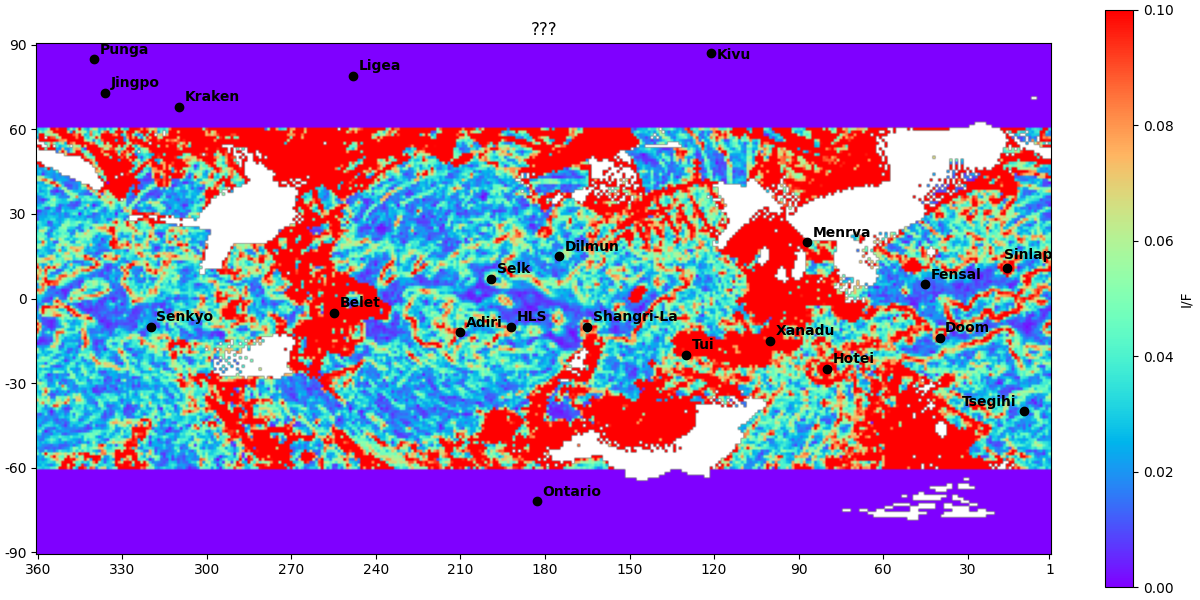

In [64]:
%matplotlib ipympl 
import matplotlib.pyplot as plt

#mapLoaded = np.load("TitanMask.titanMap.npy")

figX = 12
figY = 6

#Display Code

fig, ax = plt.subplots(figsize = (figX,figY),layout="constrained")
image = ax.imshow(npMapSimiGrad, cmap = "rainbow", vmax=0.1)
cb = plt.colorbar(image, label = "I/F")
ax.set(title = "???")
#savefilename = "TitanGlobalIoF"+wavs[WAV]+".pdf"

plt.scatter(360-192, 90+10,color="black")
plt.text(360-192+2, 90+10-2, "HLS", color="black", weight="bold")

plt.scatter(360-183, 90+72,color="black")
plt.text(360-183+2, 90+72-2, "Ontario", color="black", weight="bold")

plt.scatter(360-16, 90-11,color="black")
plt.text(360-16-1, 90-11-3, "Sinlap", color="black", weight="bold")

plt.scatter(360-310, 90-68,color="black")
plt.text(360-310+2, 90-68-2, "Kraken", color="black", weight="bold")

plt.scatter(360-248, 90-79,color="black")
plt.text(360-248+2, 90-79-2, "Ligea", color="black", weight="bold")

plt.scatter(360-340, 90-85,color="black")
plt.text(360-340+2, 90-85-1.6, "Punga", color="black", weight="bold")

plt.scatter(360-336, 90-73,color="black")
plt.text(360-336+2, 90-73-2, "Jingpo", color="black", weight="bold")

plt.scatter(360-121, 90-87,color="black")
plt.text(360-121+2, 90-87+2, "Kivu", color="black", weight="bold")

plt.scatter(360-87, 90-20,color="black")
plt.text(360-87+2, 90-20-2, "Menrva", color="black", weight="bold")

plt.scatter(360-199, 90-7,color="black")
plt.text(360-199+2, 90-7-2, "Selk", color="black", weight="bold")

plt.scatter(360-165, 90+10,color="black")
plt.text(360-165+2, 90+10-2, "Shangri-La", color="black", weight="bold")

plt.scatter(360-10, 90+40,color="black")
plt.text(360-10-22, 90+40-2, "Tsegihi", color="black", weight="bold")

plt.scatter(360-40, 90+14,color="black")
plt.text(360-40+2, 90+14-2, "Doom", color="black", weight="bold")

plt.scatter(360-210, 90+12,color="black")
plt.text(360-210+2, 90+12-2, "Adiri", color="black", weight="bold")

plt.scatter(360-175, 90-15,color="black")
plt.text(360-175+2, 90-15-2, "Dilmun", color="black", weight="bold")

plt.scatter(360-255, 90+5,color="black")
plt.text(360-255+2, 90+5-2, "Belet", color="black", weight="bold")

plt.scatter(360-320, 90+10,color="black")
plt.text(360-320+2, 90+10-2, "Senkyo", color="black", weight="bold")

plt.scatter(360-45, 90-5,color="black")
plt.text(360-45+2, 90-5-2, "Fensal", color="black", weight="bold")

plt.scatter(360-100, 90+15,color="black")
plt.text(360-100+2, 90+15-2, "Xanadu", color="black", weight="bold")
 
plt.scatter(360-130, 90+20,color="black")
plt.text(360-130+2, 90+20-2, "Tui", color="black", weight="bold")

plt.scatter(360-80, 90+25,color="black")
plt.text(360-80+2, 90+25-2, "Hotei", color="black", weight="bold")

latTicks = [0, 30, 60, 90, 120, 150, 180]
latLabels = ["90", "60", "30", "0", "-30", "-60", "-90"]
lonTicks = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 359]
lonLabels = ["360", "330", "300", "270", "240", "210", "180", "150", "120", "90", "60", "30", "1"]
ax.set_yticks(latTicks)
ax.set_yticklabels(latLabels)
ax.set_xticks(lonTicks)
ax.set_xticklabels(lonLabels)

#plt.savefig(savefilename, format="pdf")

In [25]:
x,y = 0,0
while (x < len(npMapCubes)):
    y=0
    while (y < len(npMapCubes[x])):
        if npMapCubes[x][y] == 1: print(x,y)
        y=y+1
    x=x+1

30 215
30 222
30 223
30 224
31 214
31 215
31 216
31 217
31 220
31 221
31 223
31 224
31 225
31 296
32 215
32 216
32 217
32 218
32 220
32 221
32 222
32 223
32 224
32 225
33 214
33 216
33 217
33 219
33 221
33 222
33 223
33 224
33 225
33 235
33 236
33 237
33 238
33 239
33 240
33 241
34 214
34 215
34 216
34 217
34 218
34 219
34 220
34 221
34 222
34 223
34 224
34 225
34 226
34 227
34 235
34 236
34 237
34 238
34 239
34 240
34 297
34 300
35 214
35 215
35 216
35 217
35 218
35 219
35 220
35 221
35 222
35 223
35 229
35 230
35 231
35 232
35 233
35 234
35 235
35 236
35 237
35 238
35 239
35 240
35 297
35 298
35 301
36 214
36 215
36 232
36 233
36 234
36 235
36 236
36 237
36 238
36 239
36 301
36 344
36 346
36 347
37 210
37 214
37 215
37 216
37 217
37 218
37 219
37 220
37 221
37 222
37 223
37 224
37 225
37 226
37 227
37 233
37 234
37 235
37 236
37 237
37 238
37 239
37 240
37 299
37 302
37 343
37 344
37 346
37 348
38 207
38 210
38 211
38 212
38 213
38 214
38 215
38 216
38 217
38 218
38 219
38 220
38 221

In [31]:
WAV = 4 #4 by default, 2.01 microns. 
newMap = mapGenCubeCounts(WAV,True) #Make the map. Use the stretched pixels.
np.save("TestmapGLOBAL.titanMap",newMap) #Save the map.

NameError: name 'WAV' is not defined

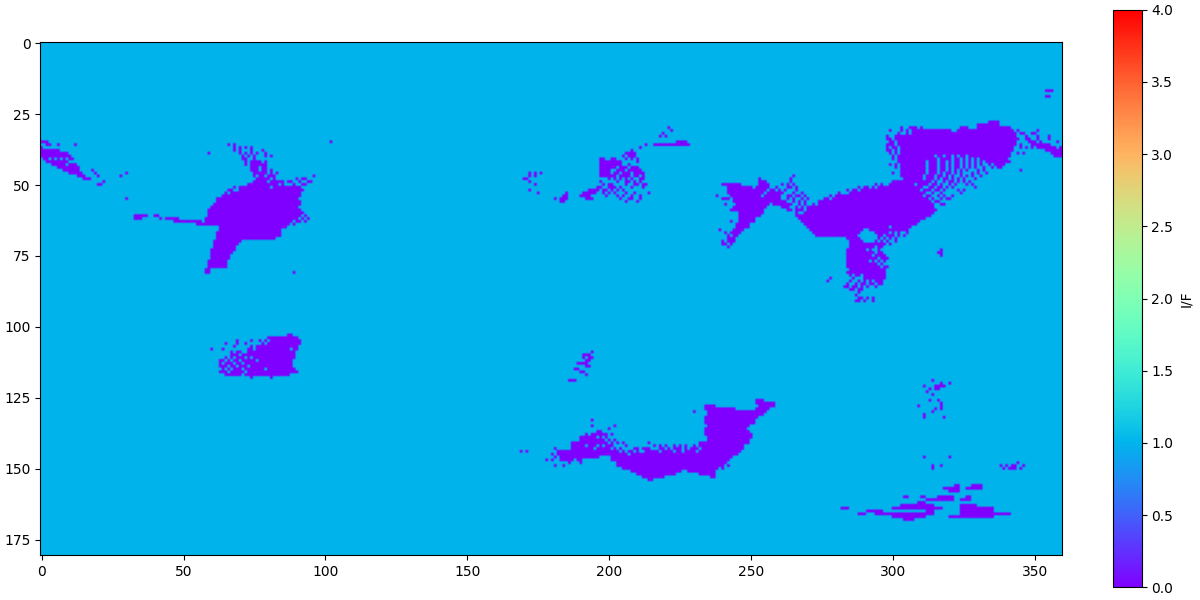

In [10]:
%matplotlib ipympl 
import matplotlib.pyplot as plt

mapLoaded = np.load("TitanMask.titanMap.npy")

figX = 12
figY = 6

#Display Code

fig, ax = plt.subplots(figsize = (figX,figY),layout="constrained")
image = ax.imshow(mapLoaded, cmap = "rainbow",vmax=4)
cb = plt.colorbar(image, label = "I/F")
ax.set(title = wavs[WAV] + " I/F")
#savefilename = "TitanGlobalIoF"+wavs[WAV]+".pdf"

plt.scatter(360-192, 90+10,color="black")
plt.text(360-192+2, 90+10-2, "HLS", color="black", weight="bold")

plt.scatter(360-183, 90+72,color="black")
plt.text(360-183+2, 90+72-2, "Ontario", color="black", weight="bold")

plt.scatter(360-16, 90-11,color="black")
plt.text(360-16-1, 90-11-3, "Sinlap", color="black", weight="bold")

plt.scatter(360-310, 90-68,color="black")
plt.text(360-310+2, 90-68-2, "Kraken", color="black", weight="bold")

plt.scatter(360-248, 90-79,color="black")
plt.text(360-248+2, 90-79-2, "Ligea", color="black", weight="bold")

plt.scatter(360-340, 90-85,color="black")
plt.text(360-340+2, 90-85-1.6, "Punga", color="black", weight="bold")

plt.scatter(360-336, 90-73,color="black")
plt.text(360-336+2, 90-73-2, "Jingpo", color="black", weight="bold")

plt.scatter(360-121, 90-87,color="black")
plt.text(360-121+2, 90-87+2, "Kivu", color="black", weight="bold")

plt.scatter(360-87, 90-20,color="black")
plt.text(360-87+2, 90-20-2, "Menrva", color="black", weight="bold")

plt.scatter(360-199, 90-7,color="black")
plt.text(360-199+2, 90-7-2, "Selk", color="black", weight="bold")

plt.scatter(360-165, 90+10,color="black")
plt.text(360-165+2, 90+10-2, "Shangri-La", color="black", weight="bold")

plt.scatter(360-10, 90+40,color="black")
plt.text(360-10-22, 90+40-2, "Tsegihi", color="black", weight="bold")

plt.scatter(360-40, 90+14,color="black")
plt.text(360-40+2, 90+14-2, "Doom", color="black", weight="bold")

plt.scatter(360-210, 90+12,color="black")
plt.text(360-210+2, 90+12-2, "Adiri", color="black", weight="bold")

plt.scatter(360-175, 90-15,color="black")
plt.text(360-175+2, 90-15-2, "Dilmun", color="black", weight="bold")

plt.scatter(360-255, 90+5,color="black")
plt.text(360-255+2, 90+5-2, "Belet", color="black", weight="bold")

plt.scatter(360-320, 90+10,color="black")
plt.text(360-320+2, 90+10-2, "Senkyo", color="black", weight="bold")

plt.scatter(360-45, 90-5,color="black")
plt.text(360-45+2, 90-5-2, "Fensal", color="black", weight="bold")

plt.scatter(360-100, 90+15,color="black")
plt.text(360-100+2, 90+15-2, "Xanadu", color="black", weight="bold")
 
plt.scatter(360-130, 90+20,color="black")
plt.text(360-130+2, 90+20-2, "Tui", color="black", weight="bold")

plt.scatter(360-80, 90+25,color="black")
plt.text(360-80+2, 90+25-2, "Hotei", color="black", weight="bold")

latTicks = [0, 30, 60, 90, 120, 150, 180]
latLabels = ["90", "60", "30", "0", "-30", "-60", "-90"]
lonTicks = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 359]
lonLabels = ["360", "330", "300", "270", "240", "210", "180", "150", "120", "90", "60", "30", "1"]
ax.set_yticks(latTicks)
ax.set_yticklabels(latLabels)
ax.set_xticks(lonTicks)
ax.set_xticklabels(lonLabels)

#plt.savefig(savefilename, format="pdf")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-142.19531651856911..63.52359825345865].


[Text(0, 0, '360'),
 Text(30, 0, '330'),
 Text(60, 0, '300'),
 Text(90, 0, '270'),
 Text(120, 0, '240'),
 Text(150, 0, '210'),
 Text(180, 0, '180'),
 Text(210, 0, '150'),
 Text(240, 0, '120'),
 Text(270, 0, '90'),
 Text(300, 0, '60'),
 Text(330, 0, '30'),
 Text(359, 0, '1')]

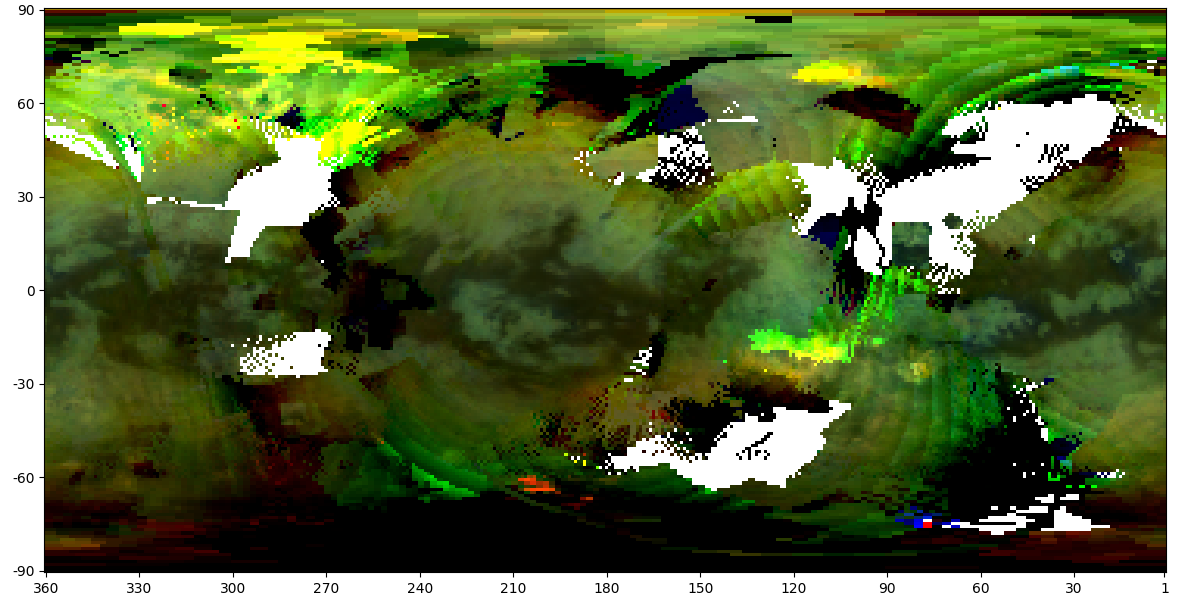

In [11]:
%matplotlib ipympl 
import matplotlib.pyplot as plt

figX = 12
figY = 6
mod=2#Carryover from color balancing in other programs...Turns out this is useful for things that are oversaturated. 

fig, ax = plt.subplots(figsize = (figX,figY),layout="constrained")

rgbMap = np.stack([(npMap7)/(mod*1.12/16), #R
                   #np.clip(map5,-0.1,0.5)*2+np.clip(map6,-0.1,0.5)*2, #G, the double window, not scaled for normal color image shenanigans.
                   (npMap4)/(mod*0.22), #G
                   (npMap2-0.03)/(mod*0.37)],axis=-1) #B

    #R = ave/(mod*1.12/16.) #Average dealing shenanigans.
    #G = temp[165-ofs]/(mod*0.22)
    #B = (temp[120-ofs]-0.03)/(mod*0.37)

plt.imshow(rgbMap, interpolation='none')

latTicks = [0, 30, 60, 90, 120, 150, 180]
latLabels = ["90", "60", "30", "0", "-30", "-60", "-90"]
lonTicks = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 359]
lonLabels = ["360", "330", "300", "270", "240", "210", "180", "150", "120", "90", "60", "30", "1"]
ax.set_yticks(latTicks)
ax.set_yticklabels(latLabels)
ax.set_xticks(lonTicks)
ax.set_xticklabels(lonLabels)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08108108108108109..7.142857142857142].


[Text(0, 0, '360'),
 Text(30, 0, '330'),
 Text(60, 0, '300'),
 Text(90, 0, '270'),
 Text(120, 0, '240'),
 Text(150, 0, '210'),
 Text(180, 0, '180'),
 Text(210, 0, '150'),
 Text(240, 0, '120'),
 Text(270, 0, '90'),
 Text(300, 0, '60'),
 Text(330, 0, '30'),
 Text(359, 0, '1')]

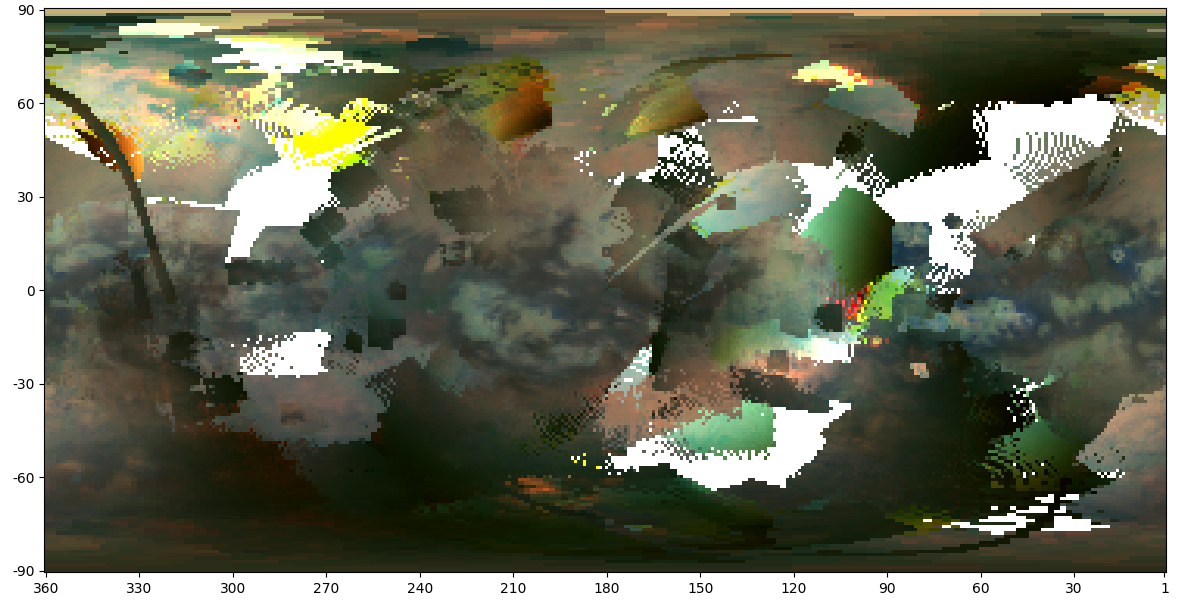

In [12]:
%matplotlib ipympl 
import matplotlib.pyplot as plt

figX = 12
figY = 6
mod=1 #Carryover from color balancing in other programs.

fig, ax = plt.subplots(figsize = (figX,figY),layout="constrained")

rgbMap = np.stack([(np.clip(npMapIF7,-0.1,0.5))/(mod*1.12/16.), #R
                   #np.clip(map5,-0.1,0.5)*2+np.clip(map6,-0.1,0.5)*2, #G, the double window, not scaled for normal color image shenanigans.
                   (np.clip(npMapIF4,-0.1,0.5))/(mod*0.22), #G
                   (np.clip(npMapIF2,-0.1,0.5)-0.03)/(mod*0.37)],axis=-1) #B

    #R = ave/(mod*1.12/16.) #Average dealing shenanigans.
    #G = temp[165-ofs]/(mod*0.22)
    #B = (temp[120-ofs]-0.03)/(mod*0.37)

plt.imshow(rgbMap, interpolation='none')

latTicks = [0, 30, 60, 90, 120, 150, 180]
latLabels = ["90", "60", "30", "0", "-30", "-60", "-90"]
lonTicks = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 359]
lonLabels = ["360", "330", "300", "270", "240", "210", "180", "150", "120", "90", "60", "30", "1"]
ax.set_yticks(latTicks)
ax.set_yticklabels(latLabels)
ax.set_xticks(lonTicks)
ax.set_xticklabels(lonLabels)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4..2.0].


[Text(0, 0, '360'),
 Text(30, 0, '330'),
 Text(60, 0, '300'),
 Text(90, 0, '270'),
 Text(120, 0, '240'),
 Text(150, 0, '210'),
 Text(180, 0, '180'),
 Text(210, 0, '150'),
 Text(240, 0, '120'),
 Text(270, 0, '90'),
 Text(300, 0, '60'),
 Text(330, 0, '30'),
 Text(359, 0, '1')]

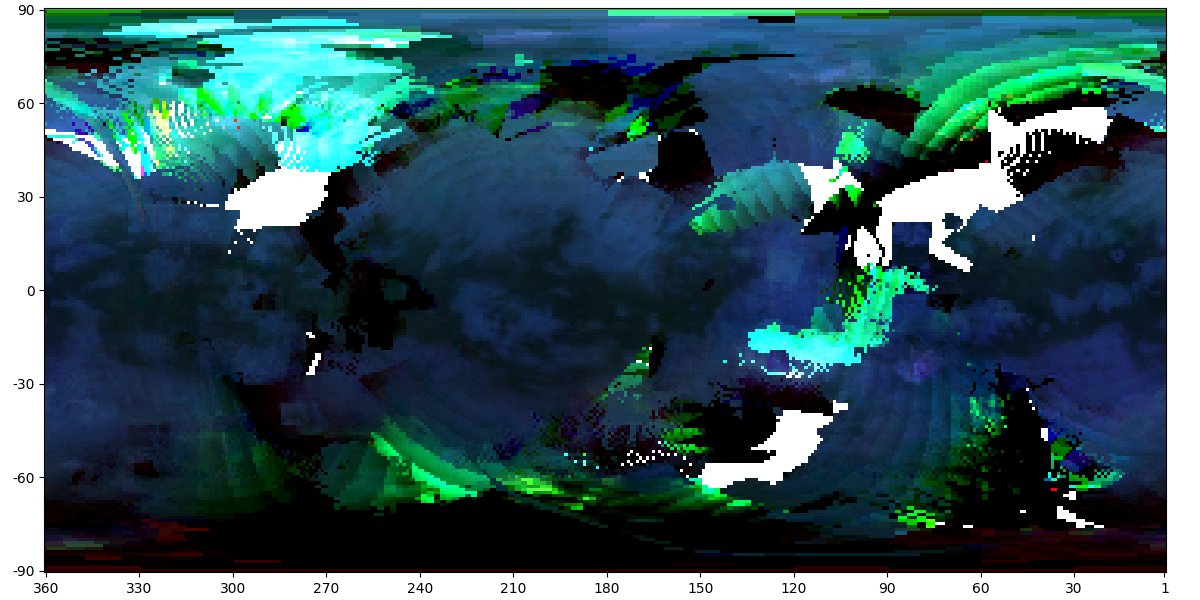

In [30]:

import matplotlib.pyplot as plt

figX = 12
figY = 6

fig, ax = plt.subplots(figsize = (figX,figY),layout="constrained")
for item in theLines:
    image = ax.plot([0,1,2,3,4,5,6,7],item,alpha=0.005,color="blue")

ax.set_ylim([-0.1,0.9])
ax.set(title = "ALL THE LINES!!!")
#savefilename = "TitanGlobalIoF"+wavs[WAV]+".pdf"

In [6]:
theLines = [] #Get the data arranged in lines in a separate cell so we don't run it millions of times.
#Ended up being a stupid idea but this code may be useful later, so leaving it around.

lat = -90
while (lat < 91):
    lon = 360
    while (lon > 0):
        theLines.append([map0[lat+90][360-lon],
                       map1[lat+90][360-lon],
                       map2[lat+90][360-lon],
                       map3[lat+90][360-lon],
                       map4[lat+90][360-lon],
                       map5[lat+90][360-lon],
                       map6[lat+90][360-lon],
                       map7[lat+90][360-lon]])
        lon = lon-1
        
    lat = lat+1


In [11]:
thing1 = [1,2,3,4,5]
thing2 = [np.nan,np.nan,np.nan,1,2,3,4,5]
print(np.nanmedian(thing1))
print(np.nanmedian(thing2))


3.0
3.0


In [2]:
#Now what we need is the length of every single thing at every point. 
#This is going to be eight I/Fs, eight Albedos, three Angles, and a cubelist.
lat = -90
while (lat < 91):
    lon = 360
    while (lon > 0):
        itemizer = [len(globalRetrievedAlbedosNew[lat+90][360-lon][0]),
                    len(globalRetrievedAlbedosNew[lat+90][360-lon][1]),
                    len(globalRetrievedAlbedosNew[lat+90][360-lon][2]),
                    len(globalRetrievedAlbedosNew[lat+90][360-lon][3]),
                    len(globalRetrievedAlbedosNew[lat+90][360-lon][4]),
                    len(globalRetrievedAlbedosNew[lat+90][360-lon][5]),
                    len(globalRetrievedAlbedosNew[lat+90][360-lon][6]),
                    len(globalRetrievedAlbedosNew[lat+90][360-lon][7]),
                    len(globalRetrievedIFNew[lat+90][360-lon][0]),
                    len(globalRetrievedIFNew[lat+90][360-lon][1]),
                    len(globalRetrievedIFNew[lat+90][360-lon][2]),
                    len(globalRetrievedIFNew[lat+90][360-lon][3]),
                    len(globalRetrievedIFNew[lat+90][360-lon][4]),
                    len(globalRetrievedIFNew[lat+90][360-lon][5]),
                    len(globalRetrievedIFNew[lat+90][360-lon][6]),
                    len(globalRetrievedIFNew[lat+90][360-lon][7]),
                    len(globalRetrievedObsAnglesNew[lat+90][360-lon][0]),
                    len(globalRetrievedObsAnglesNew[lat+90][360-lon][1]),
                    len(globalRetrievedObsAnglesNew[lat+90][360-lon][2]),
                    len(globalRetrievedCubeListNew[lat+90][360-lon])]
        if (len(set(itemizer)) > 1):
            print(lat,lon,itemizer)
        lon = lon-1         
    lat = lat+1

KeyboardInterrupt: 

In [1]:
#THE CONGLOMERATOR
#Each flyby is producing its own file. We will need to combine all the files together into one for actual proper analysis.
#The primary issue is we start with TA, then TB, then T3. So our loop needs to acount for that. 

import awkward as ak #For inhomogenous arrays, which the below are.

globalRetrievedIF = [[[[] for x in range(8)] for x in range(360)] for x in range(181)] #lat, lon, wavelength window
globalRetrievedAlbedos = [[[[] for x in range(8)] for x in range(360)] for x in range(181)] #lat, lon, wavelength window
globalRetrievedObsAngles = [[[[] for x in range(3)] for x in range(360)] for x in range(181)] #lat, lon, observation angle
globalRetrievedCubeList = [[[] for x in range(360)] for x in range(181)] #No wavelength dependence, just a list of names of cubes.

flybyIndex = 1 #Start at 1 so we can do direct-to-string conversions later. 

while (flybyIndex <= 126): 
    flybyRead = "T0" #No such thing, so if this shows up it's an oopsy indicator.
    if (flybyIndex == 1): flybyRead = "TA"
    elif (flybyIndex == 2): flybyRead = "TB"
    else: flybyRead = "T" + str(flybyIndex)
    print(flybyRead)
    globalRetrievedIFNew = ak.from_parquet("globalRetrievedIF" + flybyRead + ".parquet")
    globalRetrievedAlbedosNew = ak.from_parquet("globalRetrievedAlbedos" + flybyRead + ".parquet")
    globalRetrievedObsAnglesNew = ak.from_parquet("globalRetrievedObsAngles" + flybyRead + ".parquet")
    globalRetrievedCubeListNew = ak.from_parquet("globalRetrievedCubeList" + flybyRead + ".parquet")

    #We have read in all the data for this flyby, now it's a matter of appending *everything*. Fortunately the data sizes are the same, so this shouldn't be too difficult.
    i = 0
    while (i < 181):
        j=0
        while (j < 360):
            k = 0
            #the cubelist has no wavelength dependence.
            for item in globalRetrievedCubeListNew[i][j]:
                globalRetrievedCubeList[i][j].append(item)
            while (k < 8):
                #these two have wavelength dependence.
                for item in globalRetrievedAlbedosNew[i][j][k]:
                    globalRetrievedAlbedos[i][j][k].append(item)
                for item in globalRetrievedIFNew[i][j][k]:
                    globalRetrievedIF[i][j][k].append(item)
                k=k+1
            k=0
            while (k<3):
                #This one has observation angle type dependence.
                for item in globalRetrievedObsAnglesNew[i][j][k]:
                    globalRetrievedObsAngles[i][j][k].append(item)
                k=k+1                
            j=j+1
        i=i+1
    
    flybyIndex = flybyIndex+1

save = ak.Array(globalRetrievedIF)
ak.to_parquet(save,"globalRetrievedIFALL.parquet")

save = ak.Array(globalRetrievedAlbedos)
ak.to_parquet(save,"globalRetrievedAlbedosALL.parquet")

save = ak.Array(globalRetrievedObsAngles)
ak.to_parquet(save,"globalRetrievedObsAnglesALL.parquet")

save = ak.Array(globalRetrievedCubeList)
ak.to_parquet(save,"globalRetrievedCubeListALL.parquet")

TA
TB
T3
T4
T5
T6
T7
T8
T9
T10
T11
T12
T13
T14
T15
T16
T17
T18
T19
T20
T21
T22
T23
T24
T25
T26
T27
T28
T29
T30
T31
T32
T33
T34
T35
T36
T37
T38
T39
T40
T41
T42
T43
T44
T45
T46
T47
T48
T49
T50
T51
T52
T53
T54
T55
T56
T57
T58
T59
T60
T61
T62
T63
T64
T65
T66
T67
T68
T69
T70
T71
T72
T73
T74
T75
T76
T77
T78
T79
T80
T81
T82
T83
T84
T85
T86
T87
T88
T89
T90
T91
T92
T93
T94
T95
T96
T97
T98
T99
T100
T101
T102
T103
T104
T105
T106
T107
T108
T109
T110
T111
T112
T113
T114
T115
T116
T117
T118
T119
T120
T121
T122
T123
T124
T125
T126


  created_by: parquet-cpp-arrow version 23.0.1
  num_columns: 1
  num_rows: 181
  num_row_groups: 1
  format_version: 2.6
  serialized_size: 0

In [ ]:
#THE CONGLOMERATOR
#Each flyby is producing its own file. We will need to combine all the files together into one for actual proper analysis.
#The primary issue is we start with TA, then TB, then T3. So our loop needs to acount for that. 

import awkward as ak #For inhomogenous arrays, which the below are.

globalRetrievedIF = [[[[] for x in range(8)] for x in range(360)] for x in range(181)] #lat, lon, wavelength window

flybyIndex = 1 #Start at 1 so we can do direct-to-string conversions later. 

while (flybyIndex <= 126): 
    flybyRead = "T0" #No such thing, so if this shows up it's an oopsy indicator.
    if (flybyIndex == 1): flybyRead = "TA"
    elif (flybyIndex == 2): flybyRead = "TB"
    else: flybyRead = "T" + str(flybyIndex)
    print(flybyRead)
    globalRetrievedIFNew = ak.from_parquet("globalRetrievedIF" + flybyRead + ".parquet")

    #We have read in all the data for this flyby, now it's a matter of appending *everything*. Fortunately the data sizes are the same, so this shouldn't be too difficult.
    i = 0
    while (i < 181):
        j=0
        while (j < 360):
            k = 0
            while (k < 8):
                for item in globalRetrievedIFNew[i][j][k]:
                    globalRetrievedIF[i][j][k].append(item)
                k=k+1             
            j=j+1
        i=i+1
    
    flybyIndex = flybyIndex+1

save = ak.Array(globalRetrievedIF)
ak.to_parquet(save,"globalRetrievedIFALL.parquet")

TA
TB
T3
T4
T5
T6
T7
T8
T9
T10
T11
T12
T13
T14
T15
T16
T17
T18
T19
T20
T21
T22
T23
T24
T25
T26
T27
T28
T29
T30
T31
T32
T33
T34
T35
T36
T37
T38
T39
T40
T41
T42
T43
T44
T45
T46
T47
T48
T49
T50
T51
T52
T53
T54
T55
T56
T57
T58
T59
T60
T61
T62
T63
T64
T65
T66
T67
T68
T69
T70
T71
T72
T73
T74
T75
T76
T77
T78
T79
T80
T81
T82
T83
T84
T85
T86
T87
T88
T89
T90
T91
